### Importing libraries and SIFT init.

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# Initialize SIFT detector
sift = cv.SIFT_create()

print("OpenCV imported and SIFT detector initialized.")

OpenCV imported and SIFT detector initialized.


### Load Image and Video

In [ ]:
# Load the image
img = cv.imread('/content/sample_data/cv_cover.jpg')

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image from /content/sample_data/cv_cover.jpg")
else:
    print("Image loaded successfully.")

# Load the video
cap = cv.VideoCapture('/content/sample_data/book.mov')

# Check if video was loaded successfully
if not cap.isOpened():
    print("Error: Could not open video from /content/sample_data/book.mov")
else:
    print("Video loaded successfully.")

    # Read the first frame of the video
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read first frame from video.")
    else:
        print("First video frame read successfully.")

    # Release the video capture object
    cap.release()



Image loaded successfully.
Video loaded successfully.
First video frame read successfully.


### Convert to Grayscale and Find Keypoints

In [12]:
# Convert image to grayscale
if img is not None:
    gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Find keypoints and descriptors for the image
    kp_img, des_img = sift.detectAndCompute(gray_img, None)
    print(f"Found {len(kp_img)} keypoints in the image.")
else:
    kp_img, des_img = None, None

# Convert video frame to grayscale
if 'frame' in locals() and frame is not None:
    gray_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    # Find keypoints and descriptors for the video frame
    kp_frame, des_frame = sift.detectAndCompute(gray_frame, None)
    print(f"Found {len(kp_frame)} keypoints in the video frame.")
else:
    kp_frame, des_frame = None, None

print("Keypoints and descriptors found for image and video frame (if loaded successfully).")

Found 1205 keypoints in the image.
Found 1842 keypoints in the video frame.
Keypoints and descriptors found for image and video frame (if loaded successfully).


### Using Brute force matcher

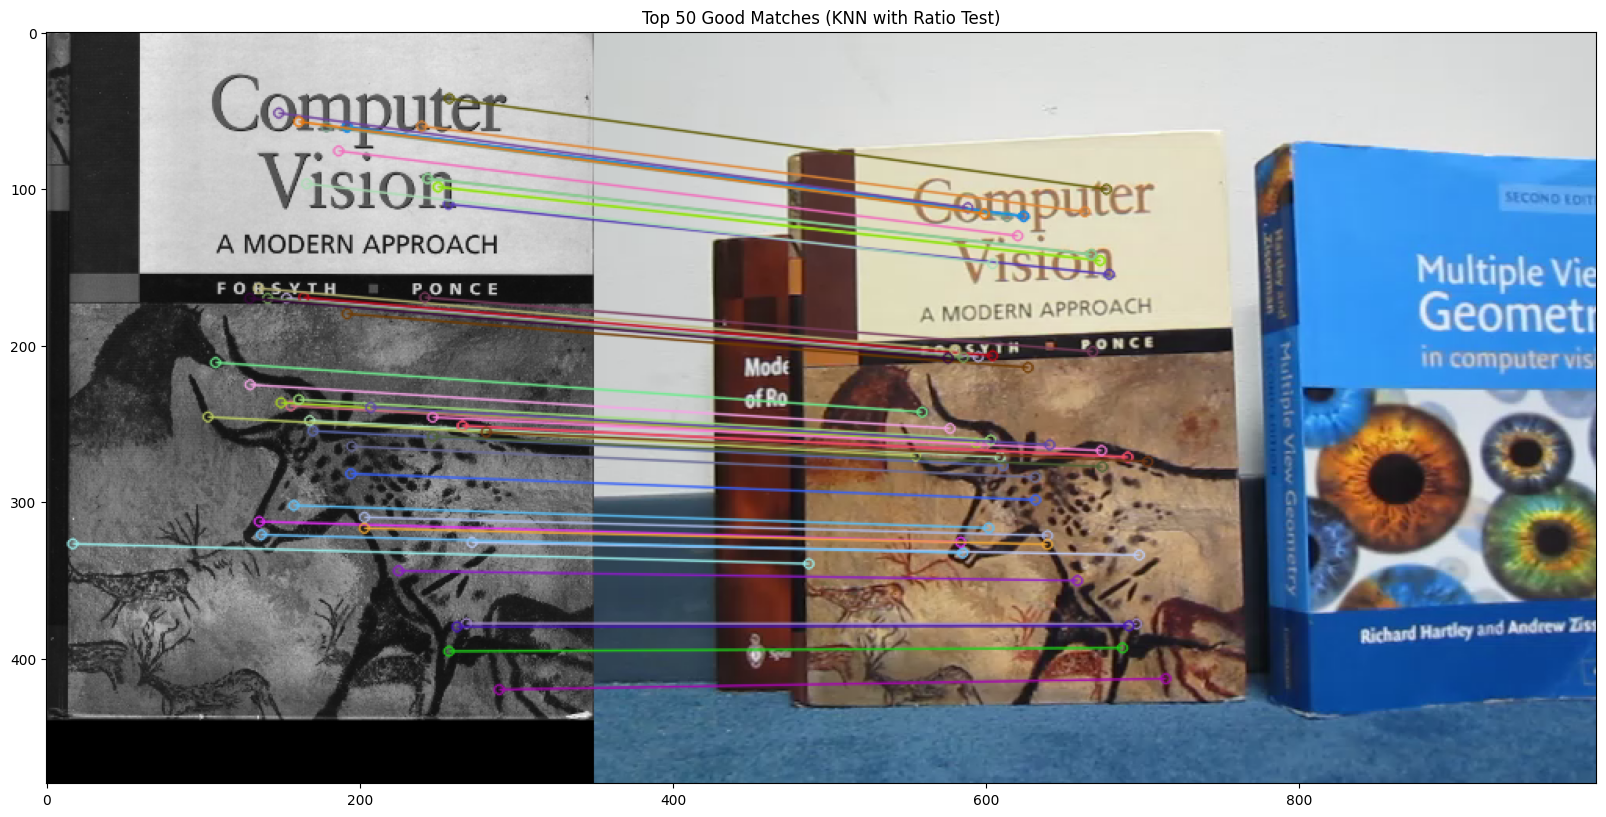

In [13]:
bfm = cv.BFMatcher_create(cv.NORM_L2) # Remove Cross-Check

# Find k=2 best matches for each descriptor
matches = bfm.knnMatch(des_img, des_frame, k=2)

# Apply ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# Sort good_matches by distance and take the top N
good_matches = sorted(good_matches, key=lambda x: x.distance)
nMatches = 50

# Draw only the top 'nMatches' good matches
img_matches = cv.drawMatches(
    img, kp_img,
    frame, kp_frame,
    good_matches[:nMatches],
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))
# Convert BGR image to RGB for matplotlib display
plt.imshow(cv.cvtColor(img_matches, cv.COLOR_BGR2RGB))
plt.title(f'Top {min(nMatches, len(good_matches))} Good Matches (KNN with Ratio Test)')
plt.show()

### Homography Function

In [ ]:
def findHomography(pts_src, pts_dst):
  if len(pts_src) < 4 or len(pts_dst) < 4:
      raise ValueError("At least 4 corresponding points are required to compute a homography.")
  if len(pts_src) != len(pts_dst):
      raise ValueError("Number of source and destination points must be equal.")

  n = pts_src.shape[0]
  A = np.zeros((2 * n, 8))
  b = np.zeros((2 * n, 1))

  for i in range(n):
      x, y = pts_src[i]
      xp, yp = pts_dst[i]

      # Construct rows for the A matrix based on the equation:
      
      A[2 * i, 0] = x
      A[2 * i, 1] = y
      A[2 * i, 2] = 1
      A[2 * i, 6] = -x * xp
      A[2 * i, 7] = -y * xp
      b[2 * i] = xp

      A[2 * i + 1, 3] = x
      A[2 * i + 1, 4] = y
      A[2 * i + 1, 5] = 1
      A[2 * i + 1, 6] = -x * yp
      A[2 * i + 1, 7] = -y * yp
      b[2 * i + 1] = yp

  # Solve the linear system Ah_vec = b_vec for h_vec (8 unknowns)
  h_vec, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

  # Reshape the 8-vector into a 3x3 Homography matrix, setting H[2,2] = 1
  H = np.zeros((3, 3))
  H[0, 0] = h_vec[0, 0]
  H[0, 1] = h_vec[1, 0]
  H[0, 2] = h_vec[2, 0]
  H[1, 0] = h_vec[3, 0]
  H[1, 1] = h_vec[4, 0]
  H[1, 2] = h_vec[5, 0]
  H[2, 0] = h_vec[6, 0]
  H[2, 1] = h_vec[7, 0]
  H[2, 2] = 1.0 # As per the problem statement

  return H

In [15]:
if good_matches:
    # Extract location of good matches
    # Source points (from img)
    pts_src = np.float32([kp_img[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    # Destination points (from frame)
    pts_dst = np.float32([kp_frame[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Calculate homography using the custom function
    H_custom = findHomography(pts_src[:, 0], pts_dst[:, 0])
    print("Custom Homography Matrix H_custom:")
    print(H_custom)

    # Test the homography with a few points
    # Let's pick the first 5 good matches for testing
    test_pts_src = pts_src[:5]
    test_pts_dst_actual = pts_dst[:5]

    print("\nTesting Homography with 5 points:")
    for i in range(len(test_pts_src)):
        src_pt = test_pts_src[i][0]
        actual_dst_pt = test_pts_dst_actual[i][0]

        # Convert source point to homogeneous coordinates (x, y, 1)
        src_pt_homogeneous = np.array([src_pt[0], src_pt[1], 1]).reshape(3, 1)

        # Transform point using homography
        transformed_pt_homogeneous = np.dot(H_custom, src_pt_homogeneous)

        # Convert back to Cartesian coordinates (x', y')
        transformed_pt = (transformed_pt_homogeneous[0:2] / transformed_pt_homogeneous[2]).flatten()

        print(f"  Source: {src_pt}")
        print(f"  Transformed: {transformed_pt}")
        print(f"  Actual Destination: {actual_dst_pt}")
        print(f"  Difference: {np.linalg.norm(transformed_pt - actual_dst_pt):.4f}\n")
else:
    print("No good matches found to calculate homography.")

Custom Homography Matrix H_custom:
[[ 6.45525585e-01 -2.57253845e-02  1.30798465e+02]
 [-1.23968102e-01  6.97703908e-01  9.17752634e+01]
 [-3.19093244e-04 -1.73776858e-04  1.00000000e+00]]

Testing Homography with 5 points:
  Source: [129.84949 225.25644]
  Transformed: [227.12630852 253.24658416]
  Actual Destination: [226.94148 253.17487]
  Difference: 0.1983

  Source: [169.9911  254.79167]
  Transformed: [259.54811463 275.62553677]
  Actual Destination: [260.78482 277.00305]
  Difference: 1.8512

  Source: [149.65019 236.72469]
  Transformed: [242.90324006 261.64464941]
  Actual Destination: [243.73103 262.51007]
  Difference: 1.1976

  Source: [191.79314   60.753185]
  Transformed: [272.60431722 118.92016812]
  Actual Destination: [273.90848  117.780266]
  Difference: 1.7321

  Source: [107.89213 211.09807]
  Transformed: [209.94450634 242.96140443]
  Actual Destination: [209.10095 242.74455]
  Difference: 0.8710



### Calculate and Draw Book Coordinates in Video Frame

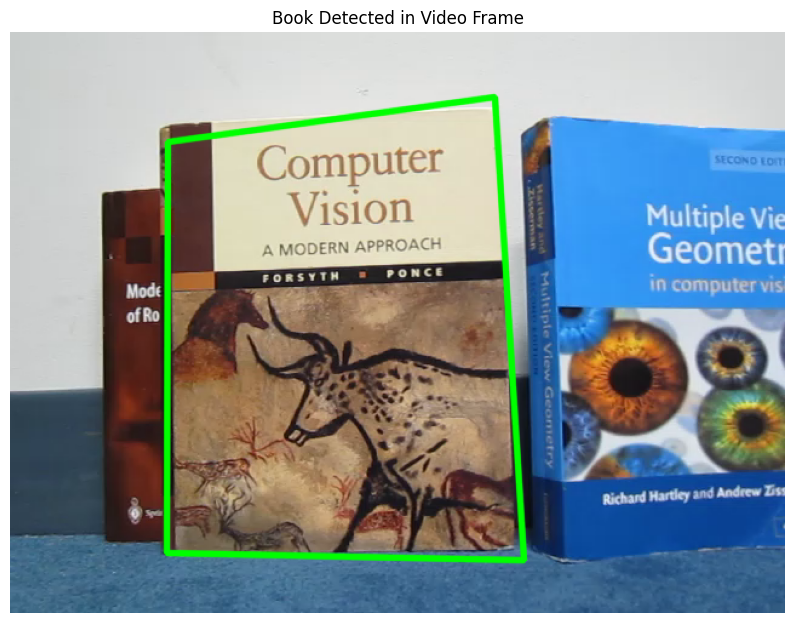

In [16]:
# Get the dimensions of the image (cover)
h, w = img.shape[:2]

# Define the four corners of the image
pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)

# Apply the homography to transform the corners to the video frame
dst = cv.perspectiveTransform(pts, H_custom)

# Draw the transformed corners on the frame
# Create a copy of the frame to draw on, so the original frame remains unchanged
frame_with_book = frame.copy()
frame_with_book = cv.polylines(frame_with_book, [np.int32(dst)], True, (0, 255, 0), 3, cv.LINE_AA)

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(frame_with_book, cv.COLOR_BGR2RGB))
plt.title('Book Detected in Video Frame')
plt.axis('off')
plt.show()

### Crop and Unwarp the Book from the Video Frame

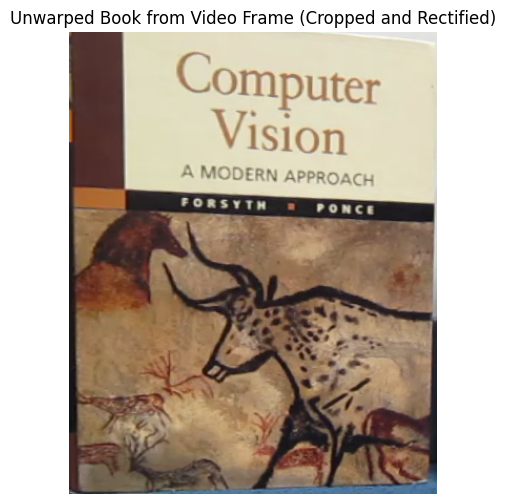

In [17]:
# Calculate the inverse homography matrix
H_custom_inverse = np.linalg.inv(H_custom)

# Get the dimensions of the original image (cover)
h_img, w_img = img.shape[:2]

# Apply the inverse homography to the video frame to unwarp the book
# The output size (dsize) will be the dimensions of the original image
warped_book = cv.warpPerspective(frame, H_custom_inverse, (w_img, h_img))

# Display the unwarped book
plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(warped_book, cv.COLOR_BGR2RGB))
plt.title('Unwarped Book from Video Frame (Cropped and Rectified)')
plt.axis('off')
plt.show()


### Crop and Unwarp 'ar_source.mov' for Overlay

ar_source.mov video loaded successfully.
First ar_source.mov frame read successfully.


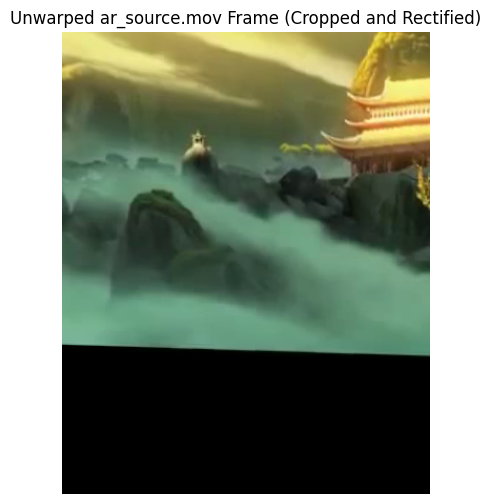

In [18]:
# Load the ar_source video
cap_ar = cv.VideoCapture('/content/sample_data/ar_source.mov')

# Check if video was loaded successfully
if not cap_ar.isOpened():
    print("Error: Could not open video from /content/sample_data/ar_source.mov")
    ar_frame = None
else:
    print("ar_source.mov video loaded successfully.")

    # Read the first frame of the video
    ret_ar, ar_frame = cap_ar.read()
    if not ret_ar:
        print("Error: Could not read first frame from ar_source.mov.")
        ar_frame = None
    else:
        print("First ar_source.mov frame read successfully.")

    # Release the video capture object
    cap_ar.release()

if ar_frame is not None:
    # Apply the inverse homography to the ar_frame
    # The output size (dsize) will be the dimensions of the original image (cover)
    warped_ar = cv.warpPerspective(ar_frame, H_custom_inverse, (w_img, h_img))

    # Display the unwarped ar_source frame
    plt.figure(figsize=(8, 6))
    plt.imshow(cv.cvtColor(warped_ar, cv.COLOR_BGR2RGB))
    plt.title('Unwarped ar_source.mov Frame (Cropped and Rectified)')
    plt.axis('off')
    plt.show()
else:
    print("Cannot proceed with ar_source.mov as the frame was not loaded.")

### Overlay 'ar_source' onto 'book.mov' frame for AR Effect

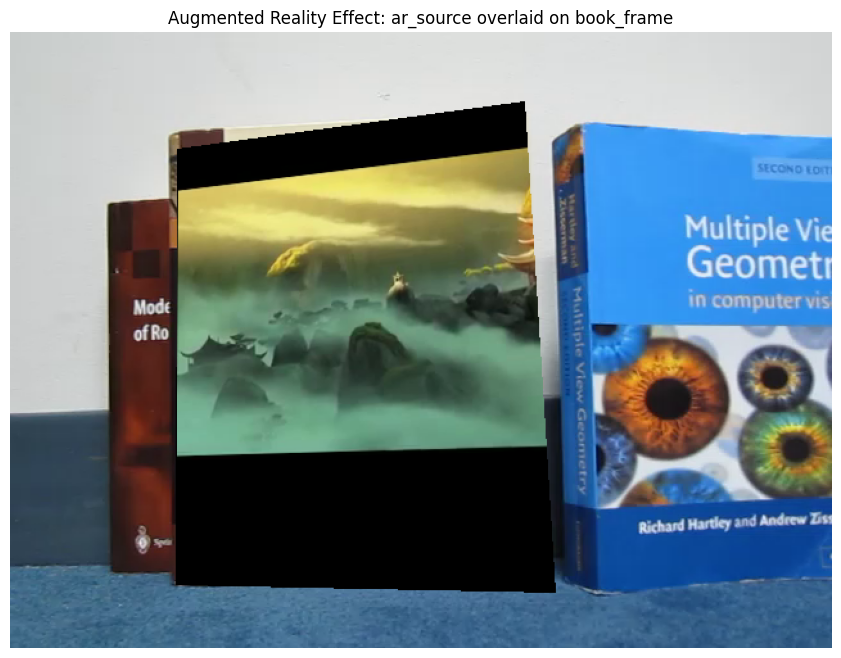

In [19]:
# Ensure 'frame' and 'ar_frame' are loaded
if frame is None or ar_frame is None:
    print("Error: 'frame' or 'ar_frame' is not loaded. Cannot proceed with overlay.")
else:
    # Get the dimensions of the video frame
    h_frame, w_frame = frame.shape[:2]

    # 1. Create a mask for the region where the book is in the 'frame'
    # The 'dst' variable holds the transformed corners of the book in the 'frame'
    mask = np.zeros((h_frame, w_frame), dtype=np.uint8)
    cv.fillConvexPoly(mask, np.int32(dst), 255)

    # 2. Invert the mask to get the background of the frame
    mask_inv = cv.bitwise_not(mask)

    # 3. Use the inverse mask to black out the book area in the original frame
    frame_bg = cv.bitwise_and(frame, frame, mask=mask_inv)

    # 4. Warp the 'ar_frame' to the perspective of the book in the 'frame'
    # The output size should be the size of the 'frame' so it can be directly overlaid
    ar_warped_to_frame = cv.warpPerspective(ar_frame, H_custom, (w_frame, h_frame))

    # 5. Use the original mask to get the foreground (warped ar_source) only where the book is
    ar_fg = cv.bitwise_and(ar_warped_to_frame, ar_warped_to_frame, mask=mask)

    # 6. Combine the background of the original frame with the warped ar_source foreground
    ar_result = cv.add(frame_bg, ar_fg)

    # Display the result
    plt.figure(figsize=(12, 8))
    plt.imshow(cv.cvtColor(ar_result, cv.COLOR_BGR2RGB))
    plt.title('Augmented Reality Effect: ar_source overlaid on book_frame')
    plt.axis('off')
    plt.show()

### Create Final AR Video

In [ ]:
# Re-open video capture objects for full video processing
cap_book = cv.VideoCapture('/content/sample_data/book.mov')
cap_ar = cv.VideoCapture('/content/sample_data/ar_source.mov')

if not cap_book.isOpened() or not cap_ar.isOpened():
    print("Error: Could not open one or both video files.")
else:
    # Get video properties
    frame_width = int(cap_book.get(cv.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap_book.get(cv.CAP_PROP_FRAME_HEIGHT))
    fps = cap_book.get(cv.CAP_PROP_FPS)

    # Define the codec and create VideoWriter object
    # Use XVID for wider compatibility or MP4V/DIVX
    fourcc = cv.VideoWriter_fourcc(*'XVID')
    out = cv.VideoWriter('ar_output.avi', fourcc, fps, (frame_width, frame_height))

    print(f"Processing video (FPS: {fps}, Resolution: {frame_width}x{frame_height})...")

    while True:
        ret_book, frame_book = cap_book.read()
        ret_ar, frame_ar = cap_ar.read()

        if not ret_book or not ret_ar:
            break # Break the loop if no more frames are available from either video

        # Convert current book frame to grayscale for SIFT
        gray_frame_book = cv.cvtColor(frame_book, cv.COLOR_BGR2GRAY)

        # Find keypoints and descriptors for the current book frame
        kp_frame_book, des_frame_book = sift.detectAndCompute(gray_frame_book, None)

        ar_result_frame = frame_book.copy() # Default to original frame_book

        if des_frame_book is not None and len(kp_frame_book) > 0:
            # Match descriptors between the cover image and the current book frame
            matches_video = bfm.knnMatch(des_img, des_frame_book, k=2)

            good_matches_video = []
            for m, n in matches_video:
                if m.distance < 0.7 * n.distance:
                    good_matches_video.append(m)

            if len(good_matches_video) > 10: # Ensure enough matches for stable homography
                # Extract location of good matches for homography calculation
                pts_src_video = np.float32([kp_img[m.queryIdx].pt for m in good_matches_video]).reshape(-1, 1, 2)
                pts_dst_video = np.float32([kp_frame_book[m.trainIdx].pt for m in good_matches_video]).reshape(-1, 1, 2)

                # Calculate homography for the current frame
                H_current_frame, mask_homography = findHomography(pts_src_video, pts_dst_video)

                if H_current_frame is not None:
                    # 1. Create a mask for the region where the book is in the 'frame_book'
                    h_book_img, w_book_img = img.shape[:2]
                    pts_corners = np.float32([[0, 0], [0, h_book_img - 1], [w_book_img - 1, h_book_img - 1], [w_book_img - 1, 0]]).reshape(-1, 1, 2)
                    dst_corners_current = cv.perspectiveTransform(pts_corners, H_current_frame)

                    mask_overlay = np.zeros((frame_height, frame_width), dtype=np.uint8)
                    cv.fillConvexPoly(mask_overlay, np.int32(dst_corners_current), 255)

                    # 2. Invert the mask for the background
                    mask_inv_overlay = cv.bitwise_not(mask_overlay)

                    # 3. Use the inverse mask to black out the book area in the original frame_book
                    frame_book_bg = cv.bitwise_and(frame_book, frame_book, mask=mask_inv_overlay)

                    # 4. Warp the current 'ar_frame' to the perspective of the book in 'frame_book'
                    ar_warped_to_current_frame = cv.warpPerspective(frame_ar, H_current_frame, (frame_width, frame_height))

                    # 5. Use the original mask to get the foreground (warped ar_source) only where the book is
                    ar_fg_overlay = cv.bitwise_and(ar_warped_to_current_frame, ar_warped_to_current_frame, mask=mask_overlay)

                    # 6. Combine the background of frame_book with the warped ar_source foreground
                    ar_result_frame = cv.add(frame_book_bg, ar_fg_overlay)
            else:
                print(f"Warning: Not enough good matches ({len(good_matches_video)}) for homography in current frame. Skipping AR overlay.")

        # Write the processed frame to the output video
        out.write(ar_result_frame)

    print("Video processing complete. Output saved to ar_output.avi")
    cap_book.release()
    cap_ar.release()
    out.release()
    cv.destroyAllWindows()

Processing video (FPS: 30.0, Resolution: 640x480)...
Video processing complete. Output saved to ar_output.avi


### Compare Original and AR Videos Side-by-Side

In [21]:
cap_original = cv.VideoCapture('/content/sample_data/book.mov')
cap_ar_output = cv.VideoCapture('/content/ar_output.avi')

if not cap_original.isOpened() or not cap_ar_output.isOpened():
    print("Error: Could not open one or both video files for comparison.")
else:
    # Get properties from the original video (assuming AR output has same dims and fps)
    frame_width_orig = int(cap_original.get(cv.CAP_PROP_FRAME_WIDTH))
    frame_height_orig = int(cap_original.get(cv.CAP_PROP_FRAME_HEIGHT))
    fps_orig = cap_original.get(cv.CAP_PROP_FPS)

    # Define the codec and create VideoWriter object for the combined video
    fourcc_combined = cv.VideoWriter_fourcc(*'XVID')
    out_combined = cv.VideoWriter('comparison_output.avi', fourcc_combined, fps_orig, (frame_width_orig * 2, frame_height_orig))

    print("Creating comparison video...")

    while True:
        ret_orig, frame_orig = cap_original.read()
        ret_ar, frame_ar = cap_ar_output.read()

        if not ret_orig or not ret_ar:
            break # Break the loop if no more frames are available from either video

        # Ensure both frames have the same dimensions if they somehow differ
        if frame_orig.shape != frame_ar.shape:
            frame_ar = cv.resize(frame_ar, (frame_width_orig, frame_height_orig))

        # Concatenate frames horizontally
        combined_frame = np.hstack((frame_orig, frame_ar))

        # Write the combined frame to the output video
        out_combined.write(combined_frame)

    print("Comparison video created: comparison_output.avi")
    cap_original.release()
    cap_ar_output.release()
    out_combined.release()
    cv.destroyAllWindows()

Creating comparison video...
Comparison video created: comparison_output.avi
